In [1]:
import subprocess
import mph
import comsol.helmholtz_pw_scattering as hlz_pw
import comsol.helmholtz_sw_scattering as hlz_sw

import matplotlib.pyplot as plt

In [2]:
process = subprocess.Popen(
    ["/Applications/COMSOL62/Multiphysics/bin/comsol", "mphserver"]
)

In [3]:
client = mph.Client(port=2036)

COMSOL Multiphysics server 6.2 (Build: 339) started listening on port 2036
Use the console command 'close' to exit the program
2025-11-12 11:22:43 A COMSOL API client with username 'mac' has logged in from 'Macs-MacBook-Air-2.local'


### Some checkouts

In [10]:
model = client.load("comsol_helholtz_sw_scattering(working).mph")

In [11]:
model.clear()
model.reset()

In [12]:
model.save()

### PW

In [13]:
parameters_pw = hlz_pw.ModelParameters()

In [14]:
model_pw = hlz_pw.create_new_model(client, parameters_pw)

In [15]:
model_pw.solve()

### SW

In [4]:
parameters_sw = hlz_sw.ModelParameters()

In [5]:
model_sw = hlz_sw.create_new_model(client, parameters_sw)

In [6]:
model_sw.solve()

In [7]:
print(client.models())

[Model('comsol_helholtz_sw_scattering(2025-11-12_11-22-43)')]


✅ get_results() executed successfully!
Line points: 21
Frequencies: [1900. 1905. 1910. 1915. 1920. 1925. 1930. 1935. 1940. 1945. 1950. 1955.
 1960. 1965. 1970. 1975. 1980. 1985. 1990. 1995. 2000.]
p_s shape: (21, 1026)


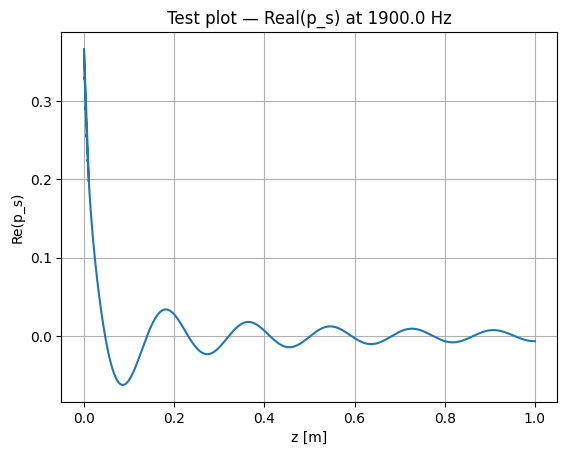

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- пробуем получить данные ---
try:
    z, freq, p_s, p_b = hlz_sw.get_results(model_sw)

    print("✅ get_results() executed successfully!")
    print(f"Line points: {len(z)}")
    print(f"Frequencies: {freq}")
    print(f"p_s shape: {np.shape(p_s)}")

    # --- простая проверка ---
    i = 0  # индекс частоты
    plt.plot(z[i], np.real(p_s[i]))
    plt.title(f"Test plot — Real(p_s) at {freq[i]} Hz")
    plt.xlabel("z [m]")
    plt.ylabel("Re(p_s)")
    plt.grid(True)
    plt.show()

except Exception as e:
    print("❌ get_results() failed with error:")
    print(e)

In [13]:
model_sw.save()

### Processing

In [16]:
freq = model_pw.evaluate("freq", "Hz")

sigma_pw = model_pw.evaluate("point_ot")
sigma_ext_pw = model_pw.evaluate("W_ext/I0/(pi*R_p^2)", "1")

sigma_sw = model_sw.evaluate("point_ot")
sigma_ext_sw = model_sw.evaluate("W_ext/I0/(pi*R_p^2)", "1")

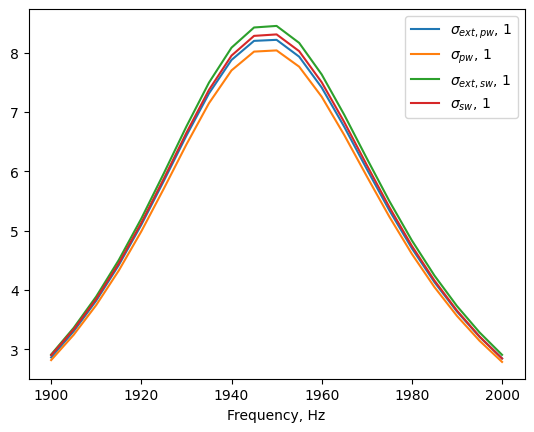

In [17]:
plt.plot(freq, sigma_ext_pw, label="$\\sigma_{ext, pw}$, 1")
plt.plot(freq, sigma_pw, label="$\\sigma_{pw}$, 1")
plt.plot(freq, sigma_ext_sw, label="$\\sigma_{ext, sw}$, 1")
plt.plot(freq, sigma_sw, label="$\\sigma_{sw}$, 1")
plt.legend()
plt.xlabel("Frequency, Hz")
plt.show()

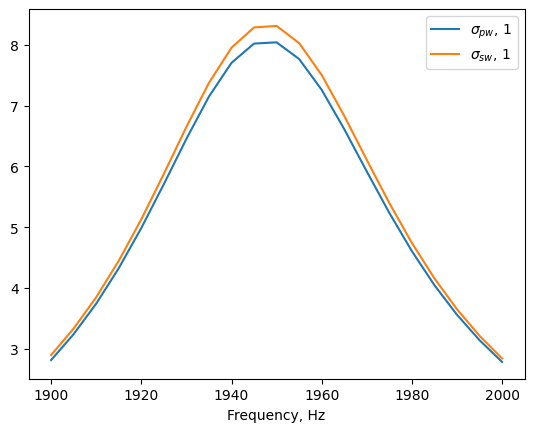

In [18]:
plt.plot(freq, sigma_pw, label="$\\sigma_{pw}$, 1")
plt.plot(freq, sigma_sw, label="$\\sigma_{sw}$, 1")
plt.legend()
plt.xlabel("Frequency, Hz")
plt.show()

In [19]:
# model_sw.clear()
model_sw.save()

In [17]:
client.disconnect()

2025-11-09 13:56:44 A COMSOL API client with username 'mac' logged in from 'Macs-MacBook-Air-2.local' has disconnected


In [18]:
process.terminate()